# 03 · 用分组验证指导优化

上一章的随机图片验证高分，不能充分预测独立样本表现。本章先修改开发验证协议，再限定候选范围、冻结选择，最后训练最终模型。

默认回放仓库内的真实实验记录，不重复训练。将 `RUN_TRAINING=True` 可完整重跑三个候选和最终训练；所有代码 cell 都可以从上到下执行。官方测试已在 v0.1 被观察过，本章只把它称作回顾性公开基准，真实相机验收还需要新的独立数据。

## 1. 选择回放或训练

回放模式读取 docs 中已保存的 JSON。训练模式建立新目录，保持旧实验可追溯。两种模式使用同一组图表代码。

In [1]:
from pathlib import Path
import sys, json
from datetime import datetime
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "cnn_tutorial").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
RUN_TRAINING = False
REPORT = ROOT / "docs" / "05_experiments" / "v0.2"
DATA = ROOT / "data" / "rps"
print("Mode:", "train" if RUN_TRAINING else "recorded experiment replay")

Mode: recorded experiment replay


## 2. 理解完整序列划分

文件名如 `paper02-031.png`：去掉最后的帧编号后，得到序列 `paper02`。每类七个序列中固定保留两个给验证，剩下五个训练。

这保证文件名序列互斥，并不证明人物身份互斥。官方测试的成员保持不变。原始 v0.1 manifest 不被覆盖。

In [2]:
from cnn_tutorial.data import download_dataset, create_manifest, create_grouped_manifest
if RUN_TRAINING:
    download_dataset(DATA)
    if not (DATA / "manifest.json").exists():
        create_manifest(DATA)
    grouped = create_grouped_manifest(DATA)
    print(grouped["held_out_groups"])
    print({split: sum(r["split"] == split for r in grouped["rows"]) for split in ("train", "val", "test")})
else:
    plan = json.loads((REPORT / "plan.json").read_text(encoding="utf-8"))
    print(plan["held_out_groups"])
    print("Recorded counts: train=1800, val=720, official test=372")

{'paper': ['paper02', 'paper04'], 'rock': ['rock04', 'rock07-k03'], 'scissors': ['scissors03', 'scissors04']}
Recorded counts: train=1800, val=720, official test=372


## 3. 预先限定候选，不看测试选模型

候选只有三个：基础配置、相同宽度加仿射增强并训练 60 轮、通道翻倍加相同增强与轮数。先保存 plan，再训练。
该对比同时改变增强与训练预算，因此不能把改进单独归因于某一种增强。宽模型与小模型之间的对比才固定了训练策略。

选模顺序是验证 accuracy、验证 loss、参数量；不查询官方测试成绩。

In [3]:
from scripts.optimize import run_study
if RUN_TRAINING:
    STUDY = ROOT / "artifacts" / ("grouped-" + datetime.now().strftime("%Y%m%d-%H%M%S-%f"))
    selection = run_study(STUDY)
else:
    STUDY = REPORT
    selection = json.loads((REPORT / "selection.json").read_text(encoding="utf-8"))
for name, summary in selection["candidates"].items():
    print(name, "params=", summary["complexity"]["parameters"],
          "val=", round(summary["validation"]["accuracy"], 4), "epoch=", summary["best_epoch"])
print("Frozen selection:", selection["selected"])

grouped-control params= 7427 val= 0.6389 epoch= 18
small-affine params= 7427 val= 0.9764 epoch= 40
wide-affine params= 26371 val= 0.9819 epoch= 36
Frozen selection: wide-affine


## 4. 仿射增强的含义

PIL 的 affine 参数描述从输出像素回到输入像素的映射，所以缩放系数使用 `1/scale`。
训练时随机旋转 ±25°、平移约 ±10%、缩放 0.8–1.15，并改变亮度/对比度。真实推理不执行这些随机变换，仍遵循灰度、64×64、除以 255 的约定。

In [4]:
import inspect
from cnn_tutorial.data import affine_augment
print(inspect.getsource(affine_augment))

def affine_augment(image):
    """Inverse affine mapping: rotation +/-25deg, scale .8-1.15, shift +/-10%."""
    angle = math.radians(random.uniform(-25, 25))
    scale = random.uniform(0.8, 1.15)
    shift_x, shift_y = random.uniform(-6.4, 6.4), random.uniform(-6.4, 6.4)
    a, b = math.cos(angle) / scale, math.sin(angle) / scale
    center_x, center_y = image.width / 2, image.height / 2
    coefficients = (a, b, center_x - a * (center_x + shift_x) - b * (center_y + shift_y),
                    -b, a, center_y + b * (center_x + shift_x) - a * (center_y + shift_y))
    return image.transform(image.size, Image.Transform.AFFINE, coefficients,
                           resample=Image.Resampling.BILINEAR, fillcolor=255)



## 5. 对比分组验证曲线

图中的每条线都来自相同的分组验证集合。不能把这个集合上的分数直接和上一章随机划分的 98.81% 当作同一种测量来排名。

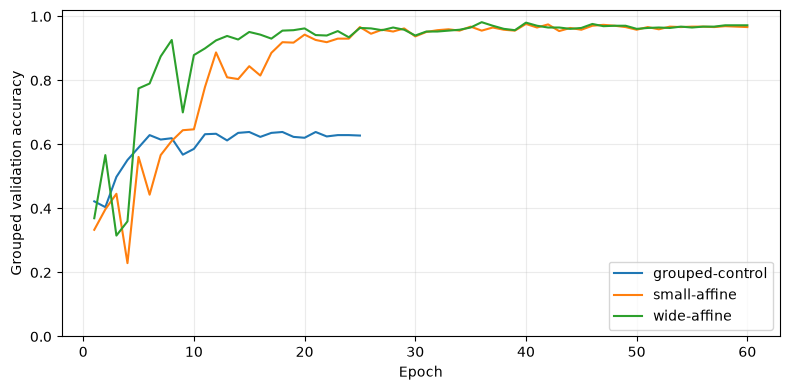

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in selection["candidates"]:
    history = json.loads((STUDY / name / "history.json").read_text(encoding="utf-8"))
    ax.plot([r["epoch"] for r in history], [r["val_accuracy"] for r in history], label=name)
ax.set(xlabel="Epoch", ylabel="Grouped validation accuracy", ylim=(0, 1.02))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 6. 用开发阶段选好的方案做最终训练

选模结束后，把原来的训练与验证合并为完整官方训练池。网络重新初始化，训练轮数来自开发阶段的最佳轮次，学习率日程保持原候选的 horizon。

最终模型不再拥有一个独立的开发验证成绩，因为这部分数据已经进入训练。这里只保存最后一轮，不能在合并后的数据上继续做早停或报告它为验证。为兼容既有评估工具，文件仍叫 best.pt，其元数据明确标注 refit final epoch。

In [6]:
from scripts.refit_selected import refit_selected
if RUN_TRAINING:
    refit = refit_selected(STUDY, DATA)
else:
    refit = json.loads((REPORT / "refit" / "summary.json").read_text(encoding="utf-8"))
print("Refit images:", refit["train_samples"])
print("Refit epochs:", refit["config"]["epochs"])
print("Independent refit validation:", refit["validation"])
print("Parameters:", refit["complexity"]["parameters"])

Refit images: 2520
Refit epochs: 36
Independent refit validation: None
Parameters: 26371


## 7. 最后才运行公开基准测试

现在可以对最终模型评估一次官方测试集。它没有进入训练或选模，但此前已经被观察，因此不是新的盲测相机验收。
默认回放保存的实测结果。训练模式写入新 run 目录中的 test_metrics.json。

In [7]:
from cnn_tutorial.training import test_checkpoint
if RUN_TRAINING:
    final_test = test_checkpoint(DATA, STUDY / "refit")
else:
    final_test = json.loads((REPORT / "refit" / "test_metrics.json").read_text(encoding="utf-8"))
print("Retrospective official benchmark accuracy:", f"{final_test['accuracy']:.2%}")
print("Macro-F1:", final_test["macro_f1"])
print("Confusion matrix (true rows / predicted columns):", final_test["confusion_matrix"])

Retrospective official benchmark accuracy: 95.70%
Macro-F1: 0.9562668648125919
Confusion matrix (true rows / predicted columns): [[108, 11, 5], [0, 124, 0], [0, 0, 124]]


## 下一步与语法速查

下一阶段将固定最终权重、预处理与类别表，检查 PyTorch→Keras 数值一致性，再使用训练池代表性样本进行 INT8 校准。真实相机背景类、跨人/跨会话测试和板上速度仍未完成。

- `rsplit('-', 1)`：只从右边分割一次，保留序列名内部的其他连字符。
- `dataclass`：明确保存训练配置字段，避免参数散落。
- `min(..., key=...)`：根据一组固定排序规则选择候选；负 accuracy 表示优先取准确率高者。
- `sha256`：记录数据与权重内容的身份，用于检查是否发生变化。
- 开发验证、最终训练和最终测试是不同角色；一组图片一旦用于训练，就不能继续称作独立验证。